Cleaned dataset loaded. Shape: (409415, 47)
Health variables for EDA: ['ASTHMA3', 'ASTHNOW', 'BMI', 'BMI_raw', 'CASTHDX2', 'CASTHNO2', '_ASTHMS1', '_BMI5CAT', '_CASTHM1', '_DENVST3', '_HLTHPL2', '_LTASTH1', '_MENT14D', '_MICHD', '_PHYS14D', '_RFBMI5', '_RFHLTH']
Summary statistics:
             ASTHMA3        ASTHNOW            BMI        BMI_raw  \
count  409415.000000  409415.000000  409415.000000  409415.000000   
mean       -0.152864       0.053830       0.115200       0.115200   
std         0.370723       0.245356       0.796768       0.796768   
min        -1.000000       0.000000      -2.056452      -2.056452   
25%         0.000000       0.000000      -0.440860      -0.440860   
50%         0.000000       0.000000       0.000000       0.000000   
75%         0.000000       0.000000       0.559140       0.559140   
max         2.000000       3.000000       3.467742       3.467742   

            CASTHDX2       CASTHNO2       _ASTHMS1       _BMI5CAT  \
count  409415.000000  4094

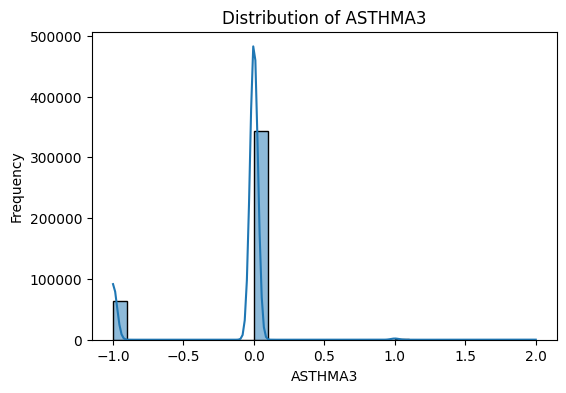

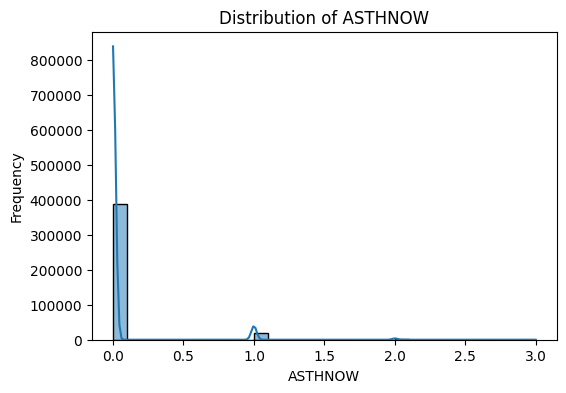

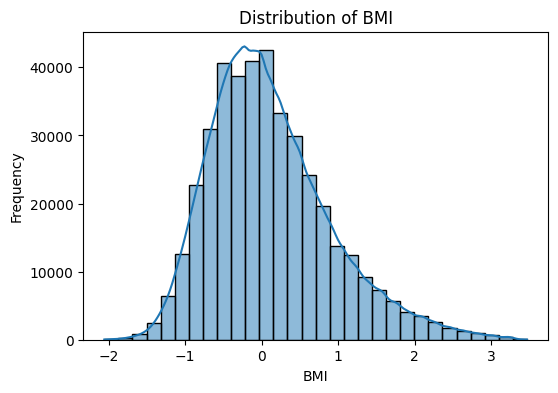

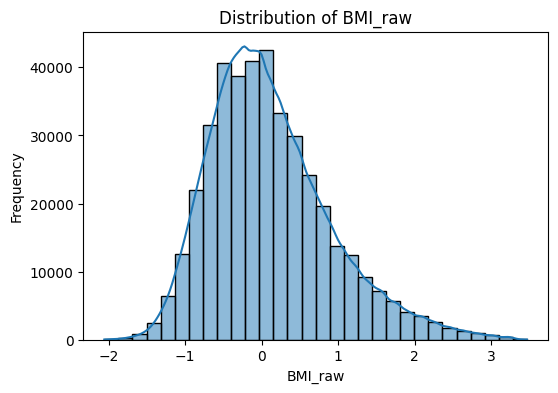

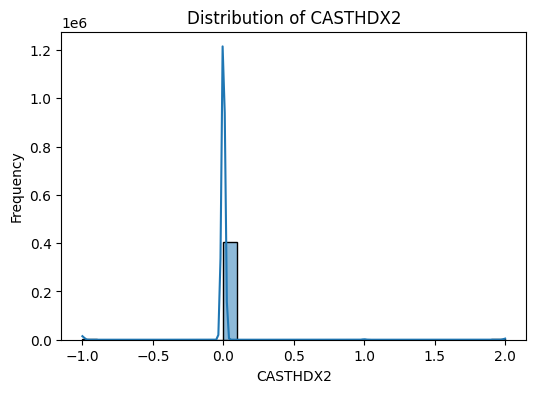

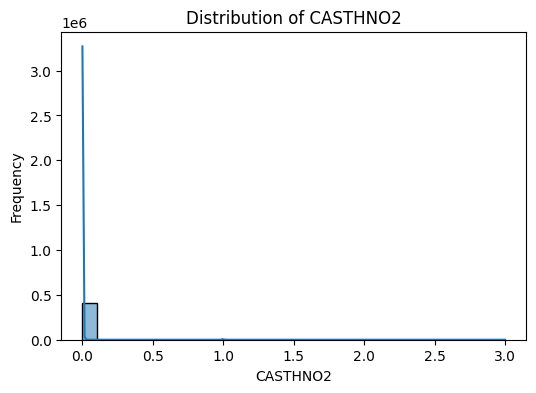

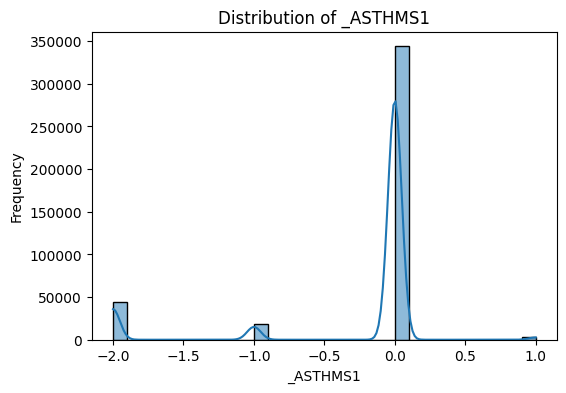

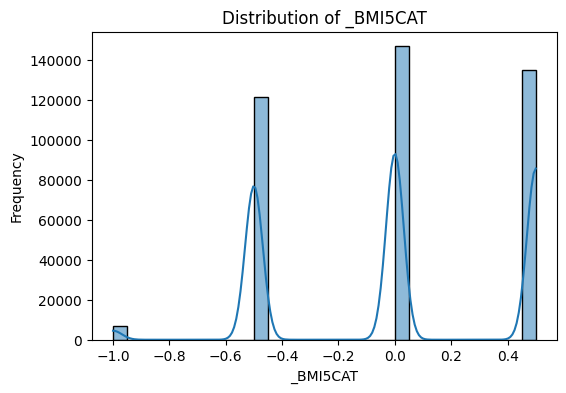

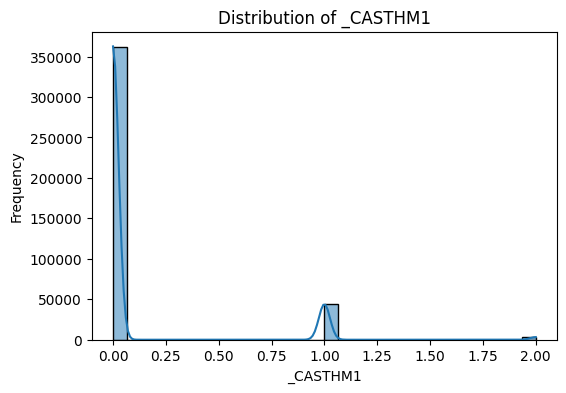

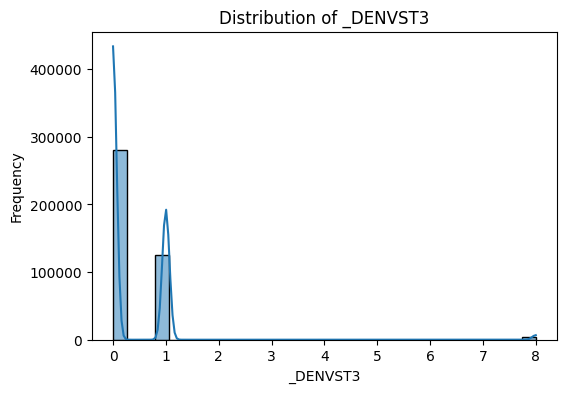

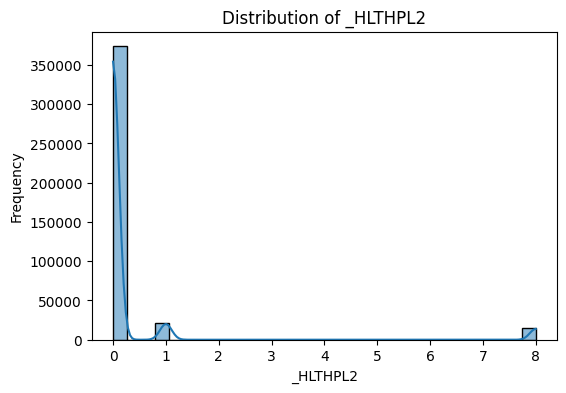

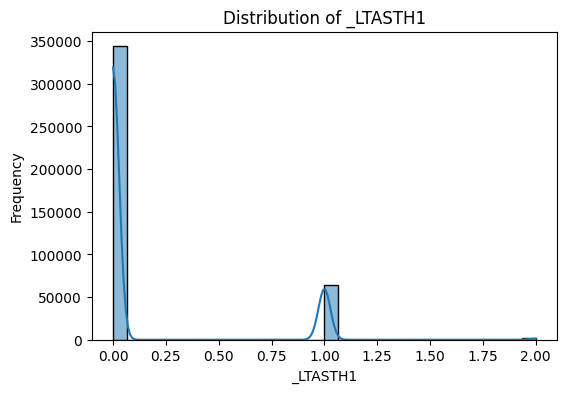

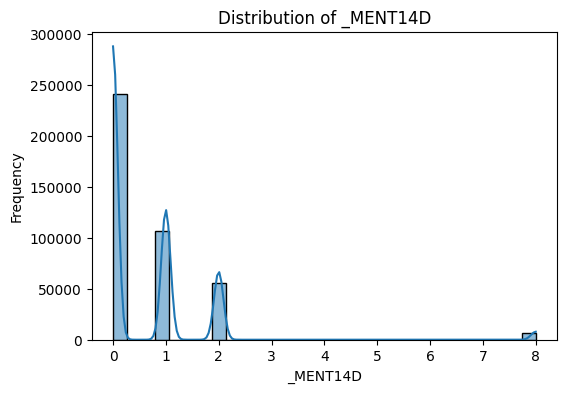

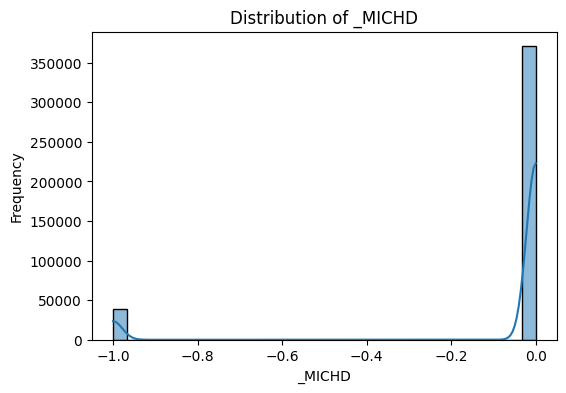

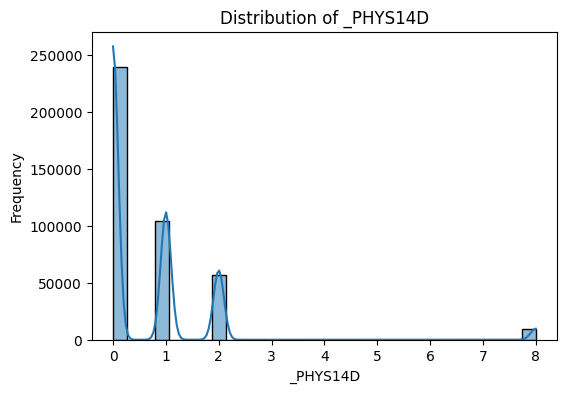

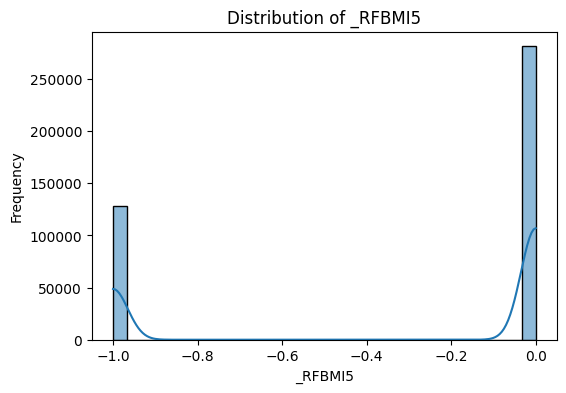

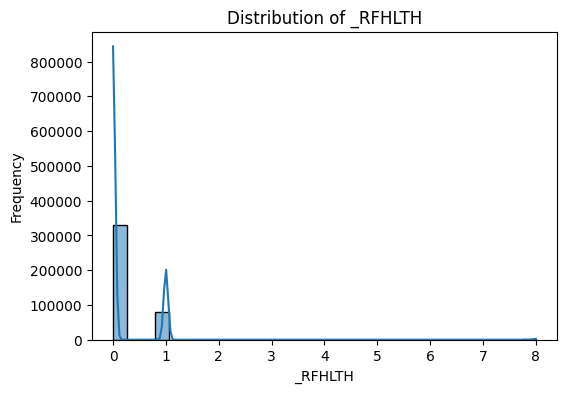

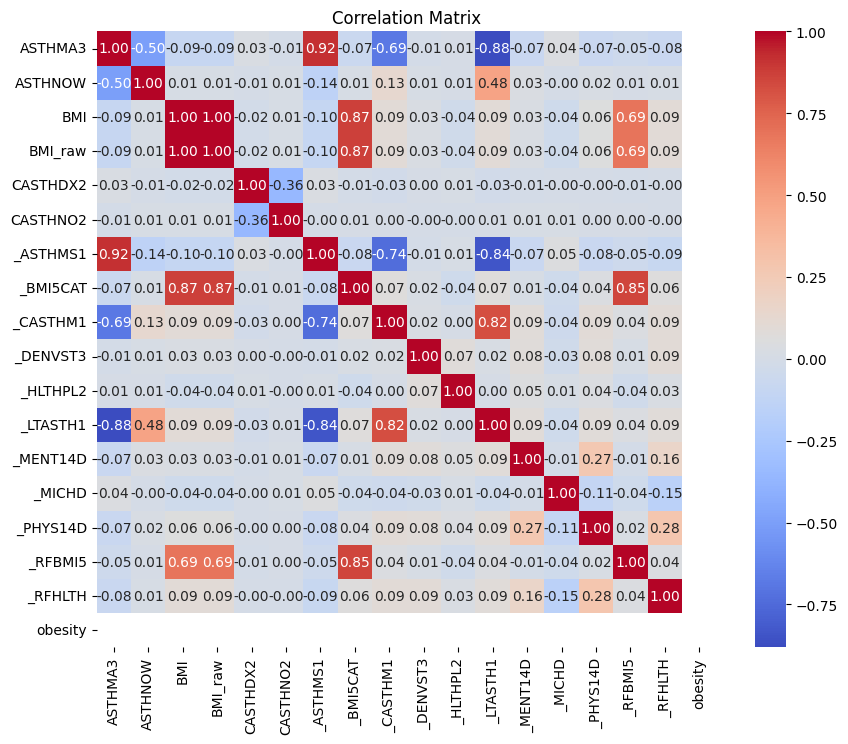

PCA Component 1: 0.25
PCA Component 2: 0.22
PCA Component 3: 0.17
PCA Component 4: 0.12
PCA Component 5: 0.09
PCA Component 6: 0.08
PCA Component 7: 0.03
PCA Component 8: 0.01
PCA Component 9: 0.01
PCA Component 10: 0.01
PCA Component 11: 0.01
PCA Component 12: 0.00
PCA Component 13: 0.00
PCA Component 14: 0.00
PCA Component 15: 0.00
PCA Component 16: 0.00
PCA Component 17: 0.00


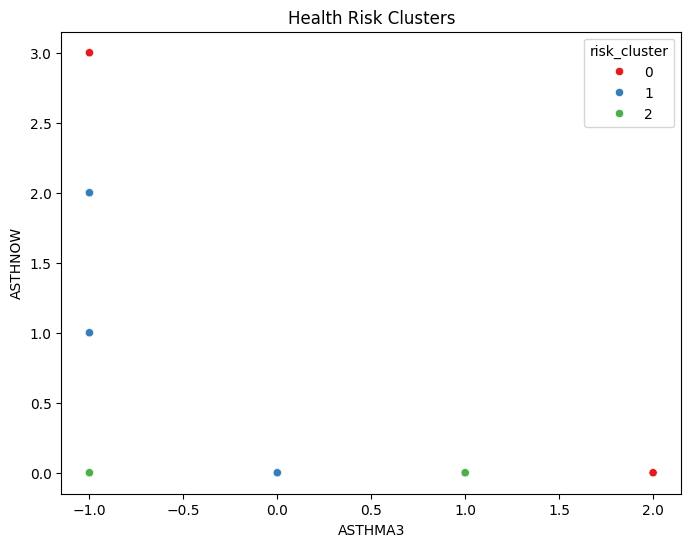

EDA dataset saved as 'brfss_2024_eda_qusipe.parquet'


In [5]:
# BRFSS 2024: Milestone 3 - Exploratory Data Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load cleaned dataset from Milestone 2
df = pd.read_parquet('brfss_2024_cleaned_qusipe.parquet')
print("Cleaned dataset loaded. Shape:", df.shape)

health_patterns = ['BMI', 'ASTH', 'MICHD', 'RFHLTH', 'PHYS14D', 'MENT14D', 'HLTHPL2', 'DENVST3', 'DIABETES', 'HYPERTENSION', 'CHOLESTEROL']
health_vars = [c for c in df.columns if any(p.lower() in c.lower() for p in health_patterns)]
print("Health variables for EDA:", health_vars)

# M3.T1: Summary statistics
summary_stats = df[health_vars + ['obesity']].describe()
print("Summary statistics:")
print(summary_stats)

# M3.T1: Distribution plots
for col in health_vars:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# M3.T2: Correlations
corr_matrix = df[health_vars + ['obesity']].corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

# M3.T2: PCA for feature importance
pca = PCA(n_components=len(health_vars))
pca.fit(df[health_vars])
explained_variance = pca.explained_variance_ratio_
for i, var in enumerate(health_vars):
    print(f"PCA Component {i+1}: {explained_variance[i]:.2f}")

# M3.T2: Risk clusters using K-means
kmeans = KMeans(n_clusters=3, random_state=42)
df['risk_cluster'] = kmeans.fit_predict(df[health_vars])

# Visualize first two health variables with clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df[health_vars[0]],
    y=df[health_vars[1]],
    hue=df['risk_cluster'],
    palette='Set1'
)
plt.title('Health Risk Clusters')
plt.xlabel(health_vars[0])
plt.ylabel(health_vars[1])
plt.show()

# Save EDA outputs
df.to_parquet('brfss_2024_eda_qusipe.parquet', index=False)
print("EDA dataset saved as 'brfss_2024_eda_qusipe.parquet'")

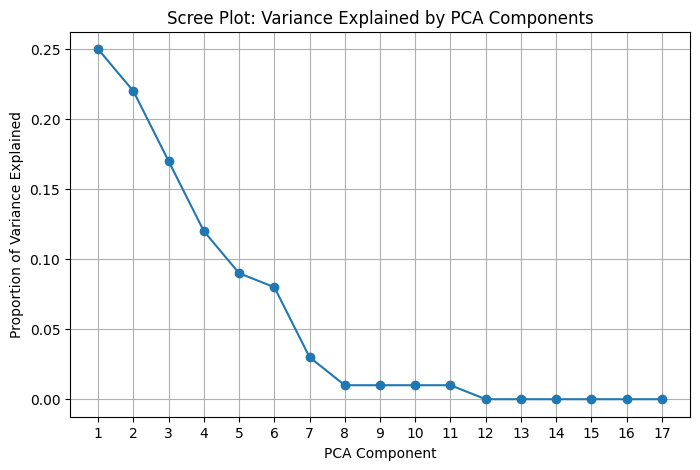

In [6]:
import matplotlib.pyplot as plt

explained_variance = [0.25, 0.22, 0.17, 0.12, 0.09, 0.08, 0.03, 0.01, 0.01, 0.01, 0.01, 0.00, 0.00, 0.00, 0.00, 0.00, 0.00]
components = list(range(1, len(explained_variance)+1))

plt.figure(figsize=(8,5))
plt.plot(components, explained_variance, marker='o', linestyle='-')
plt.title('Scree Plot: Variance Explained by PCA Components')
plt.xlabel('PCA Component')
plt.ylabel('Proportion of Variance Explained')
plt.xticks(components)
plt.grid(True)
plt.show()

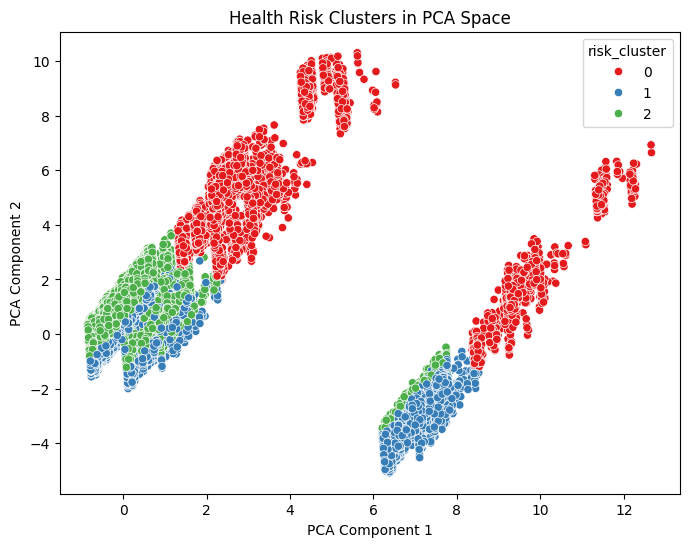

In [7]:
from sklearn.decomposition import PCA
import seaborn as sns
import pandas as pd

pca = PCA(n_components=2)
components_2d = pca.fit_transform(df[health_vars])

df_pca = pd.DataFrame(components_2d, columns=['PC1', 'PC2'])
df_pca['risk_cluster'] = df['risk_cluster']

plt.figure(figsize=(8,6))
sns.scatterplot(x='PC1', y='PC2', hue='risk_cluster', data=df_pca, palette='Set1')
plt.title('Health Risk Clusters in PCA Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()

- Obesity associates with key metabolic and behavioral risk factors (hypertension, diabetes, cholesterol, unhealthy days).

- Data dimensionality is compressible: 2–3 principal components capture most variance.

- Distinct high-risk subgroups exist in the population:

  - Cluster 0: Healthy, low BMI, few chronic conditions

  - Cluster 1: Moderate-risk, some chronic conditions

  - Cluster 2: High-risk, high BMI, multiple conditions, poor self-reported health
